In [ ]:
import cv2
import pandas as pd
import json
import os
import shutil
from IPython.display import display, Image
from google.colab import files

In [ ]:
uploaded = files.upload()

uploaded_files = list(uploaded.keys())

print("Uploaded files:")
for file in uploaded_files:
    print("-", file)

Saving tackle_events.json to tackle_events.json
Saving afl_video.mp4 to afl_video.mp4
Uploaded files:
- tackle_events.json
- afl_video.mp4


In [ ]:
video_file = None
csv_file = None
json_file = None

for file in uploaded_files:
    lower_file = file.lower()

    if lower_file.endswith((".mp4", ".avi", ".mov", ".mkv")):
        video_file = file

    elif lower_file.endswith(".csv"):
        csv_file = file

    elif lower_file.endswith(".json"):
        json_file = file

print("Detected files:")
print("Video file:", video_file)
print("CSV file:", csv_file)
print("JSON file:", json_file)

if video_file is None:
    raise ValueError("No video file found. Please upload an .mp4, .avi, .mov, or .mkv file.")

if csv_file is None and json_file is None:
    raise ValueError("No tackle output file found. Please upload either a .csv or .json file.")

Detected files:
Video file: afl_video.mp4
CSV file: None
JSON file: tackle_events.json


In [ ]:
OUTPUT_FOLDER = "validation_frames"
VALIDATION_OUTPUT = "tackle_event_validation.csv"
ZIP_OUTPUT = "validation_frames.zip"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Output folder created:", OUTPUT_FOLDER)
print("Validation CSV will be saved as:", VALIDATION_OUTPUT)

Output folder created: validation_frames
Validation CSV will be saved as: tackle_event_validation.csv


In [ ]:
video = cv2.VideoCapture(video_file)

fps = video.get(cv2.CAP_PROP_FPS)
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

if fps == 0:
    raise ValueError("Could not read the video FPS. The video file may not have loaded correctly.")

duration_seconds = total_frames / fps

print("Video information:")
print("FPS:", fps)
print("Total frames:", total_frames)
print("Duration:", round(duration_seconds, 2), "seconds")

video.release()

Video information:
FPS: 29.92336806816739
Total frames: 17955
Duration: 600.03 seconds


In [ ]:
def frame_to_timestamp(frame_number, fps):
    seconds = frame_number / fps

    minutes = int(seconds // 60)
    remaining_seconds = int(seconds % 60)

    return f"{minutes:02d}:{remaining_seconds:02d}"

In [ ]:
def load_events_from_json(json_path):
    with open(json_path, "r") as file:
        data = json.load(file)

    events = []

    if isinstance(data, list):
        event_list = data

    elif isinstance(data, dict):
        event_list = (
            data.get("events") or
            data.get("tackle_events") or
            data.get("detected_events") or
            []
        )

    else:
        event_list = []

    for i, event in enumerate(event_list, start=1):
        start_frame = (
            event.get("start_frame") or
            event.get("frame_start") or
            event.get("start") or
            event.get("startFrame")
        )

        end_frame = (
            event.get("end_frame") or
            event.get("frame_end") or
            event.get("end") or
            event.get("endFrame")
        )

        if start_frame is not None and end_frame is not None:
            events.append({
                "event_id": i,
                "start_frame": int(start_frame),
                "end_frame": int(end_frame)
            })

    return pd.DataFrame(events)

In [ ]:
def group_consecutive_frames(frames):
    frames = sorted(frames)

    if len(frames) == 0:
        return []

    grouped_events = []
    current_group = [frames[0]]

    for frame in frames[1:]:
        if frame == current_group[-1] + 1:
            current_group.append(frame)
        else:
            grouped_events.append(current_group)
            current_group = [frame]

    grouped_events.append(current_group)

    return grouped_events

In [ ]:
def load_events_from_csv(csv_path):
    df = pd.read_csv(csv_path)

    print("CSV columns found:")
    print(df.columns.tolist())

    possible_start_columns = ["start_frame", "frame_start", "start", "startFrame"]
    possible_end_columns = ["end_frame", "frame_end", "end", "endFrame"]

    start_col = None
    end_col = None

    for col in possible_start_columns:
        if col in df.columns:
            start_col = col
            break

    for col in possible_end_columns:
        if col in df.columns:
            end_col = col
            break

    if start_col is not None and end_col is not None:
        events = []

        for i, row in df.iterrows():
            events.append({
                "event_id": i + 1,
                "start_frame": int(row[start_col]),
                "end_frame": int(row[end_col])
            })

        return pd.DataFrame(events)

    possible_frame_columns = ["frame_id", "frame", "frame_number", "frameNumber"]

    frame_col = None

    for col in possible_frame_columns:
        if col in df.columns:
            frame_col = col
            break

    if frame_col is None:
        raise ValueError(
            "No valid frame column found. Expected start/end frame columns or a frame_id/frame/frame_number column."
        )

    frames = sorted(df[frame_col].dropna().astype(int).unique().tolist())

    grouped_frames = group_consecutive_frames(frames)

    events = []

    for i, group in enumerate(grouped_frames, start=1):
        events.append({
            "event_id": i,
            "start_frame": min(group),
            "end_frame": max(group),
            "event_length_frames": len(group)
        })

    return pd.DataFrame(events)

In [ ]:
events_df = None

if json_file is not None:
    print("Loading events from JSON file:", json_file)
    events_df = load_events_from_json(json_file)

    if len(events_df) == 0:
        print("JSON file was found, but no events were loaded. Trying CSV instead.")

if (events_df is None or len(events_df) == 0) and csv_file is not None:
    print("Loading events from CSV file:", csv_file)
    events_df = load_events_from_csv(csv_file)

if events_df is None or len(events_df) == 0:
    raise ValueError("No tackle events could be loaded from the uploaded files.")

print("Loaded tackle events:")
display(events_df)

Loading events from JSON file: tackle_events.json
Loaded tackle events:


,event_id,start_frame,end_frame
0,1,2113,2119
1,2,3514,3544
2,3,3556,3580
3,4,3592,3601
4,5,5089,5097
5,6,5123,5141
6,7,5193,5199
7,8,5538,5542
8,9,14172,14186
9,10,14492,14502


In [ ]:
events_df["start_time"] = events_df["start_frame"].apply(lambda x: frame_to_timestamp(x, fps))
events_df["end_time"] = events_df["end_frame"].apply(lambda x: frame_to_timestamp(x, fps))

display(events_df)

,event_id,start_frame,end_frame,start_time,end_time
0,1,2113,2119,01:10,01:10
1,2,3514,3544,01:57,01:58
2,3,3556,3580,01:58,01:59
3,4,3592,3601,02:00,02:00
4,5,5089,5097,02:50,02:50
5,6,5123,5141,02:51,02:51
6,7,5193,5199,02:53,02:53
7,8,5538,5542,03:05,03:05
8,9,14172,14186,07:53,07:54
9,10,14492,14502,08:04,08:04


In [ ]:
def extract_frame(video_path, frame_number, output_path):
    video = cv2.VideoCapture(video_path)

    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = video.read()

    if success:
        cv2.imwrite(output_path, frame)

    video.release()

    return success

In [ ]:
MAX_EVENTS_TO_PREVIEW = 30

preview_paths = []
middle_frames = []

events_to_process = events_df.head(MAX_EVENTS_TO_PREVIEW).copy()

video = cv2.VideoCapture(video_file)

if not video.isOpened():
    raise ValueError("Could not open the video file.")

for _, row in events_to_process.iterrows():
    event_id = int(row["event_id"])
    start_frame = int(row["start_frame"])
    end_frame = int(row["end_frame"])

    middle_frame = (start_frame + end_frame) // 2
    middle_frames.append(middle_frame)

    output_path = os.path.join(
        OUTPUT_FOLDER,
        f"event_{event_id}_frame_{middle_frame}.jpg"
    )

    if middle_frame < 0 or middle_frame >= total_frames:
        preview_paths.append("Frame outside video range")
        continue

    video.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
    success, frame = video.read()

    if success:
        cv2.imwrite(output_path, frame)
        preview_paths.append(output_path)
    else:
        preview_paths.append("Frame extraction failed")

video.release()

events_to_process["middle_frame"] = middle_frames
events_to_process["preview_image"] = preview_paths

display(events_to_process)

,event_id,start_frame,end_frame,start_time,end_time,middle_frame,preview_image
0,1,2113,2119,01:10,01:10,2116,validation_frames/event_1_frame_2116.jpg
1,2,3514,3544,01:57,01:58,3529,validation_frames/event_2_frame_3529.jpg
2,3,3556,3580,01:58,01:59,3568,validation_frames/event_3_frame_3568.jpg
3,4,3592,3601,02:00,02:00,3596,validation_frames/event_4_frame_3596.jpg
4,5,5089,5097,02:50,02:50,5093,validation_frames/event_5_frame_5093.jpg
5,6,5123,5141,02:51,02:51,5132,validation_frames/event_6_frame_5132.jpg
6,7,5193,5199,02:53,02:53,5196,validation_frames/event_7_frame_5196.jpg
7,8,5538,5542,03:05,03:05,5540,validation_frames/event_8_frame_5540.jpg
8,9,14172,14186,07:53,07:54,14179,validation_frames/event_9_frame_14179.jpg
9,10,14492,14502,08:04,08:04,14497,validation_frames/event_10_frame_14497.jpg


Event ID: 1
Frame range: 2113 to 2119
Video time: 01:10 to 01:10
Middle frame: 2116


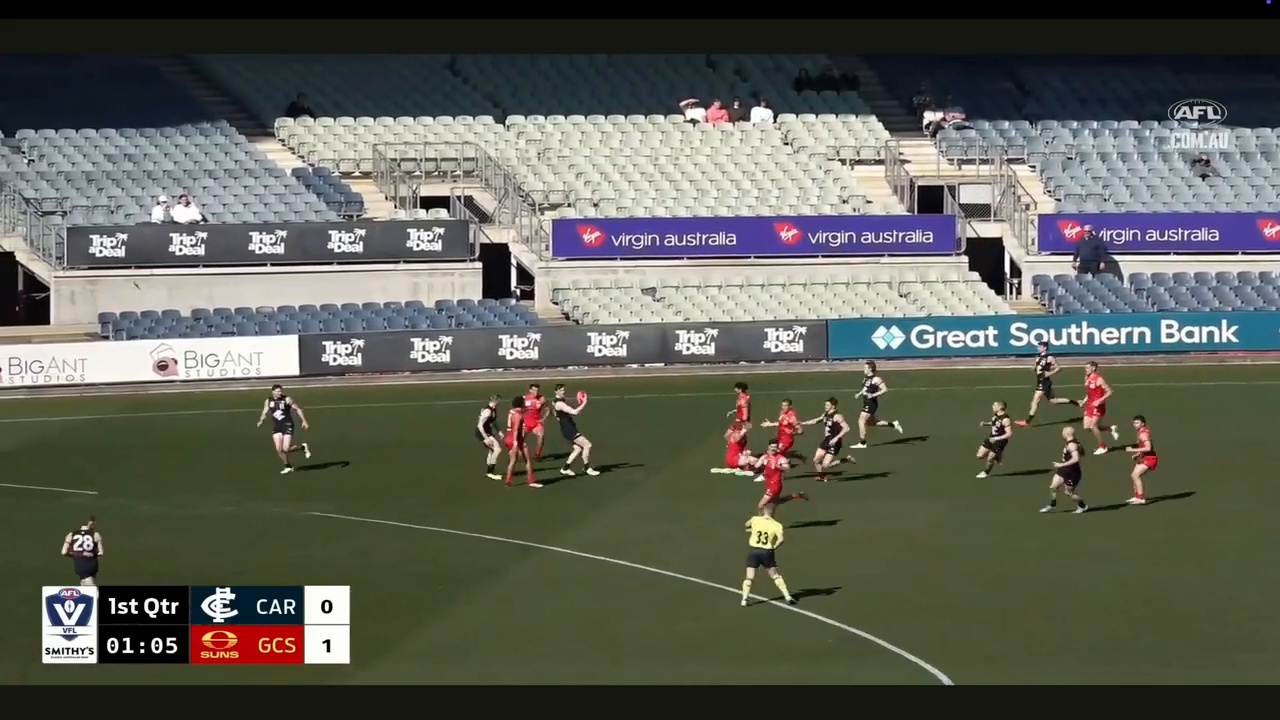

Event ID: 2
Frame range: 3514 to 3544
Video time: 01:57 to 01:58
Middle frame: 3529


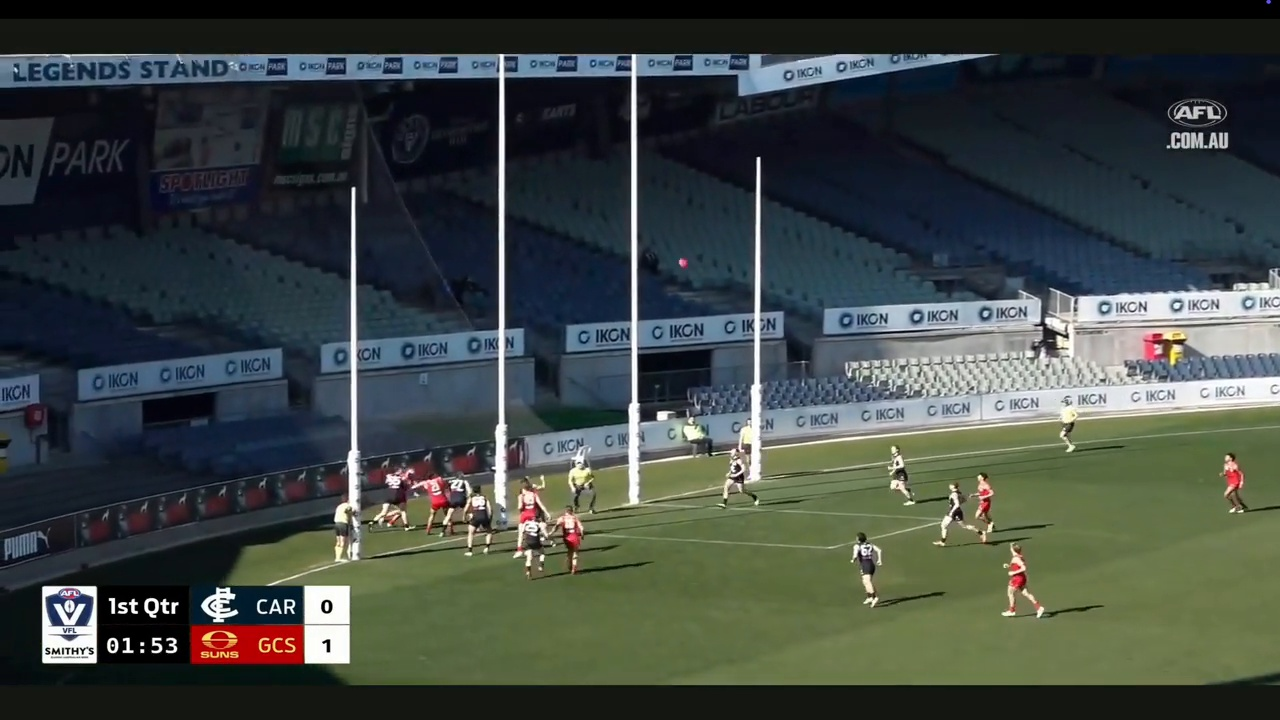

Event ID: 3
Frame range: 3556 to 3580
Video time: 01:58 to 01:59
Middle frame: 3568


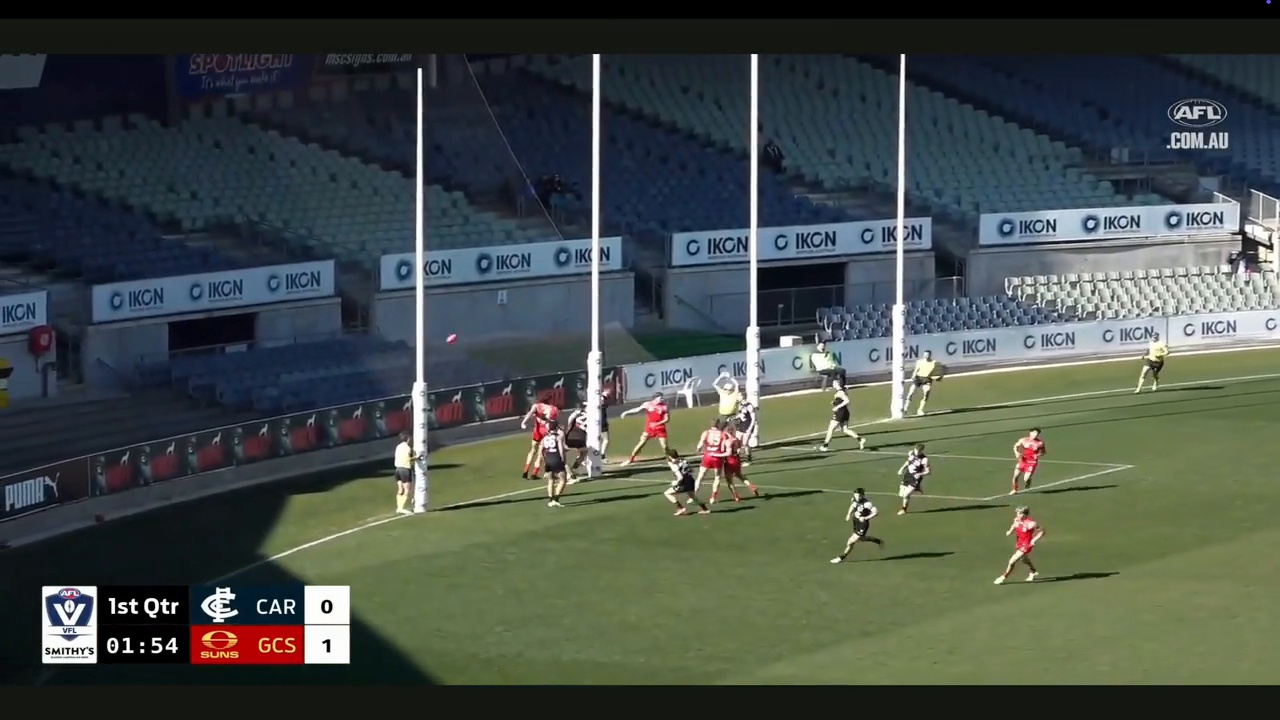

Event ID: 4
Frame range: 3592 to 3601
Video time: 02:00 to 02:00
Middle frame: 3596


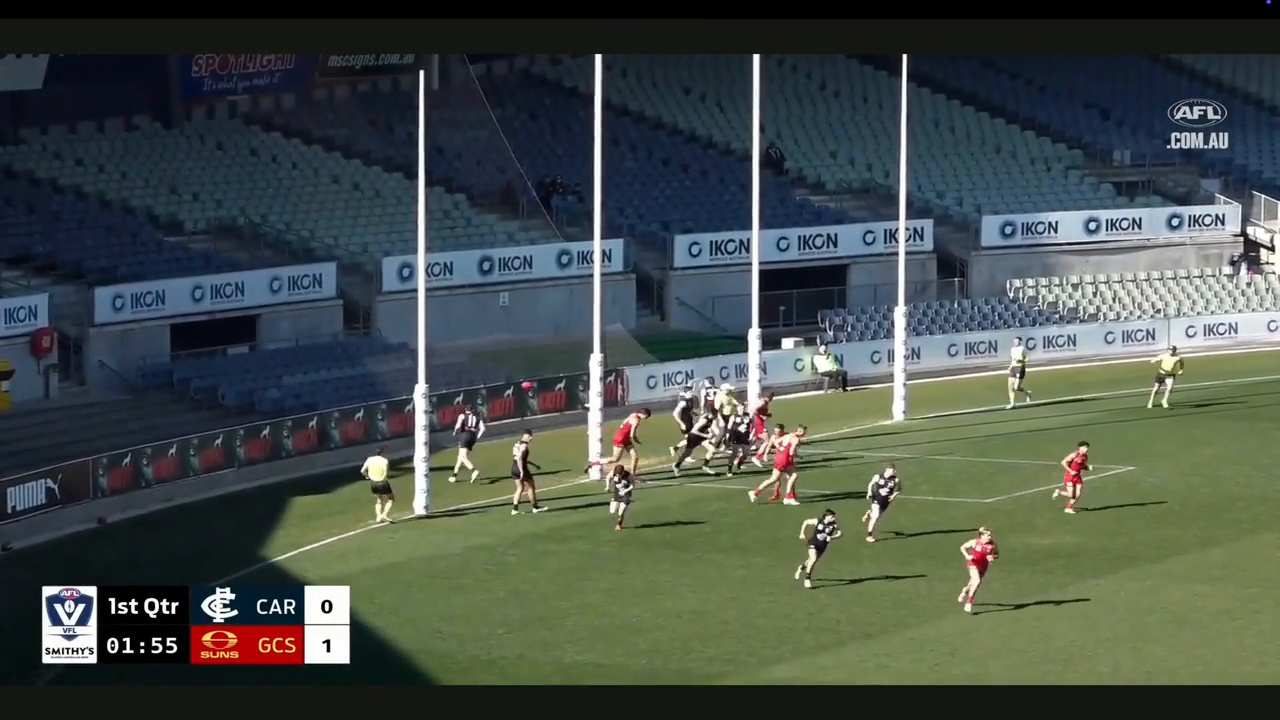

Event ID: 5
Frame range: 5089 to 5097
Video time: 02:50 to 02:50
Middle frame: 5093


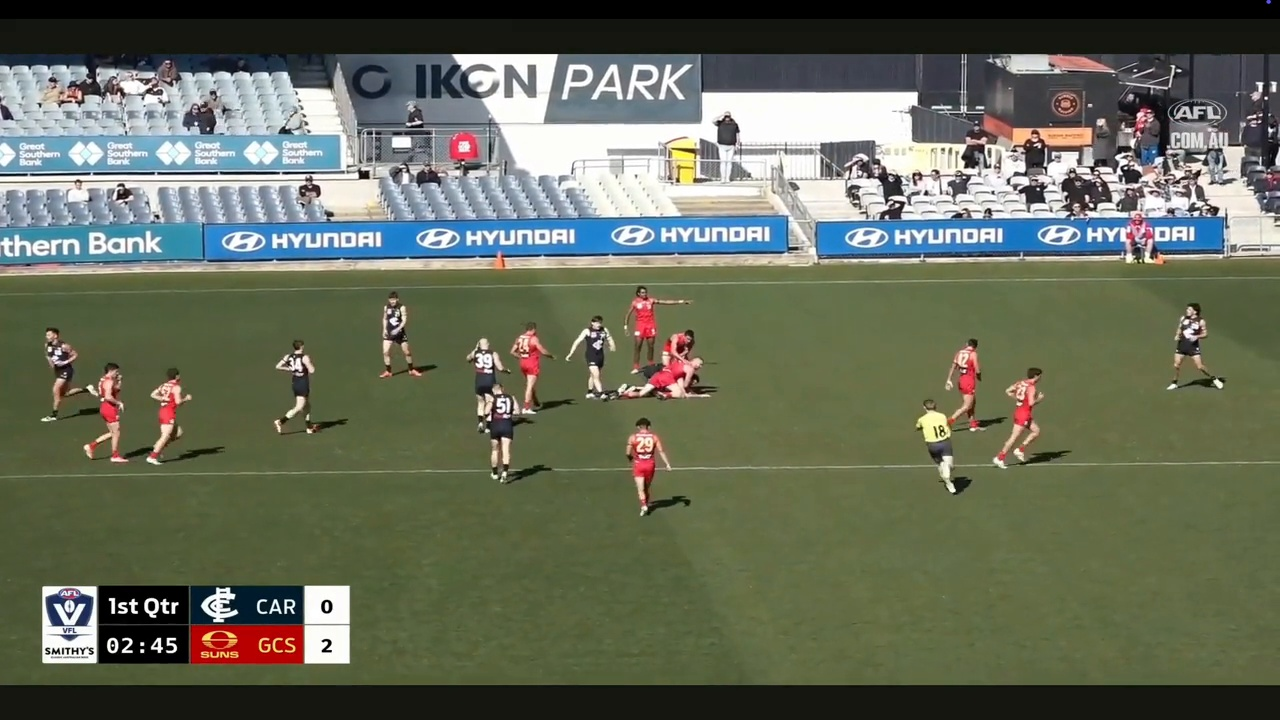

Event ID: 6
Frame range: 5123 to 5141
Video time: 02:51 to 02:51
Middle frame: 5132


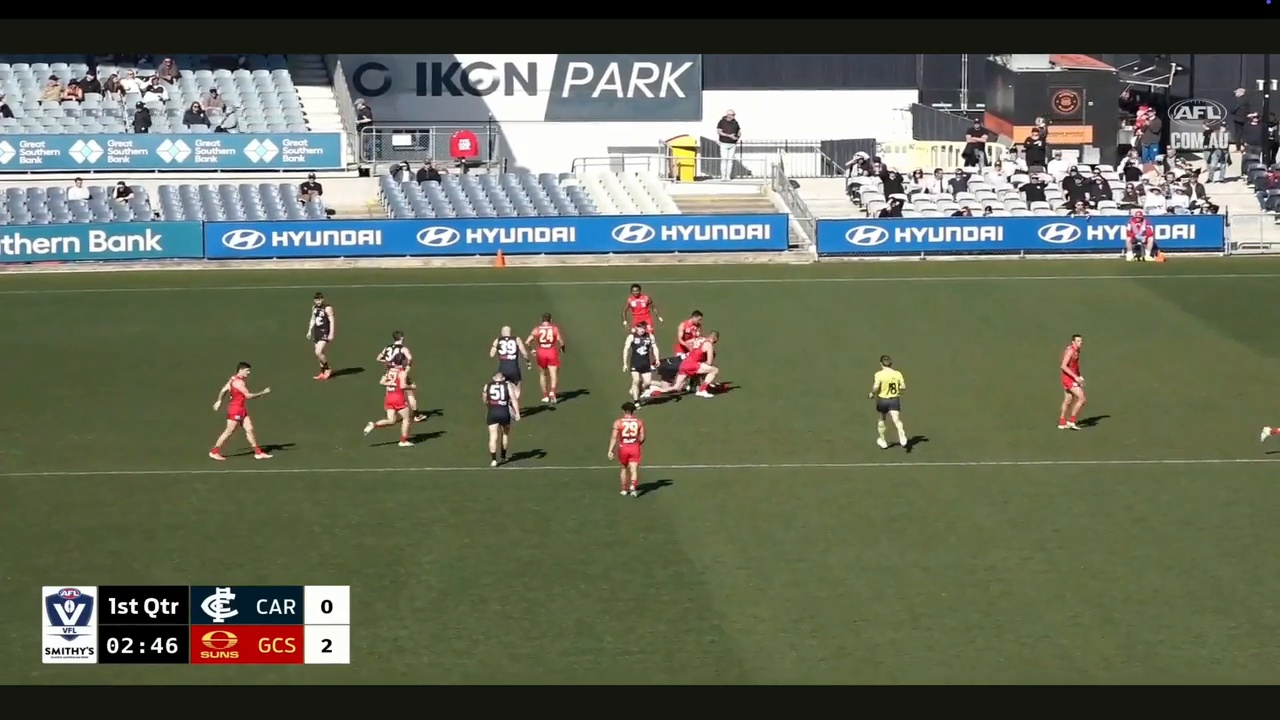

Event ID: 7
Frame range: 5193 to 5199
Video time: 02:53 to 02:53
Middle frame: 5196


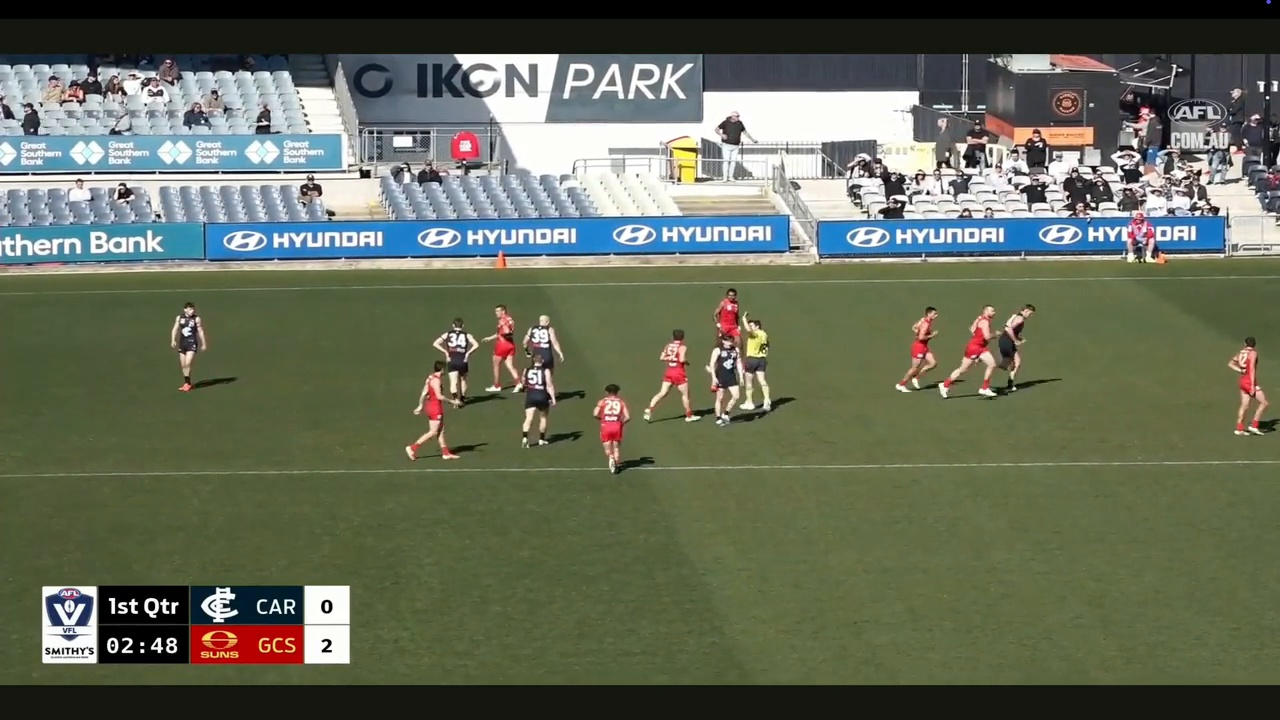

Event ID: 8
Frame range: 5538 to 5542
Video time: 03:05 to 03:05
Middle frame: 5540


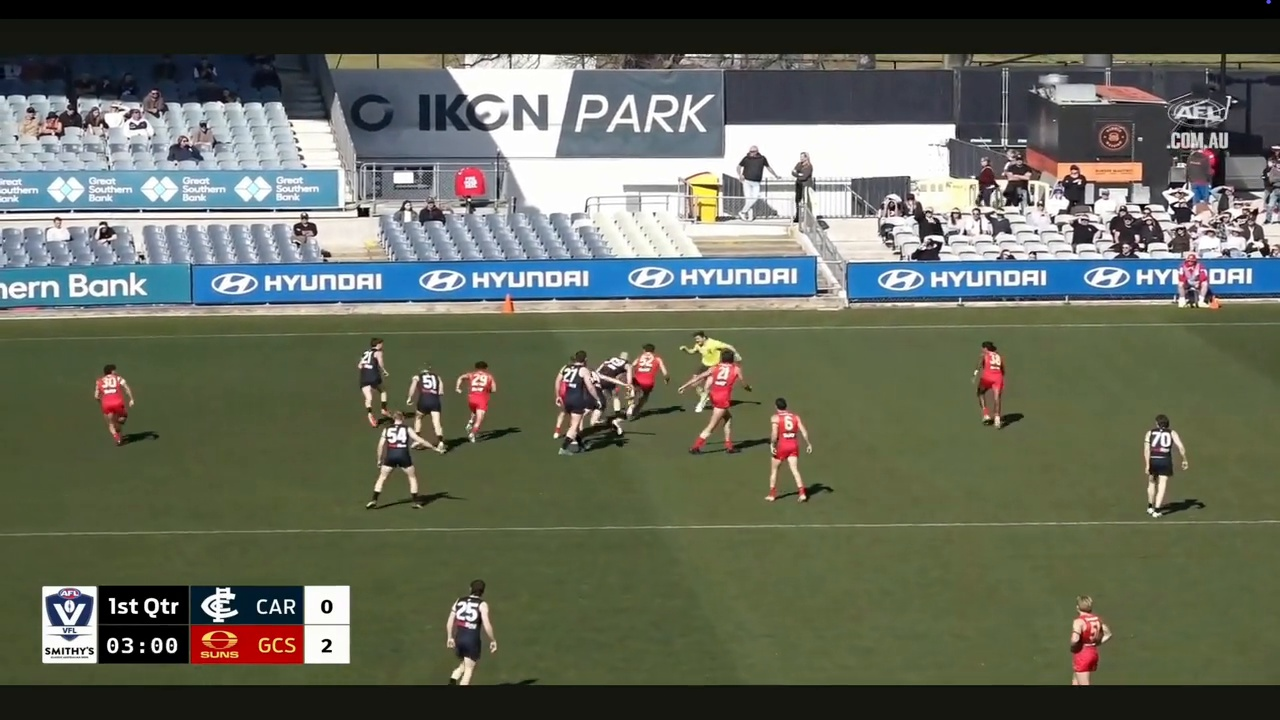

Event ID: 9
Frame range: 14172 to 14186
Video time: 07:53 to 07:54
Middle frame: 14179


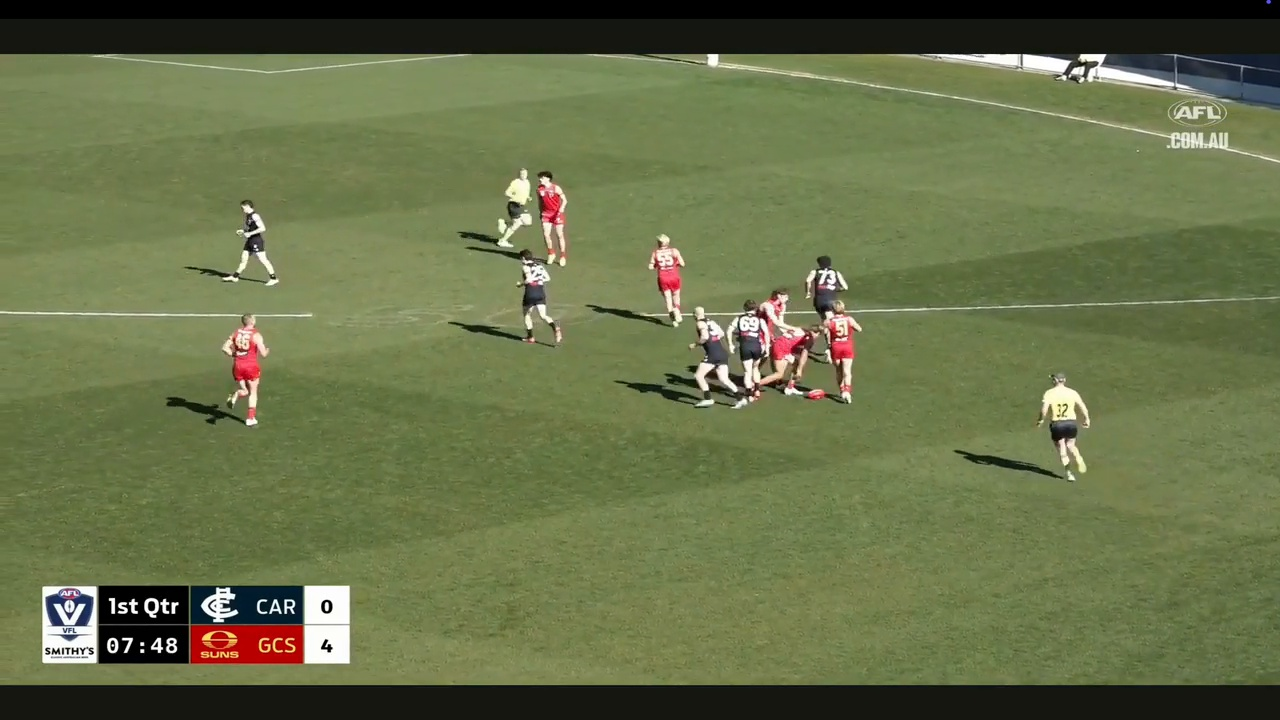

Event ID: 10
Frame range: 14492 to 14502
Video time: 08:04 to 08:04
Middle frame: 14497


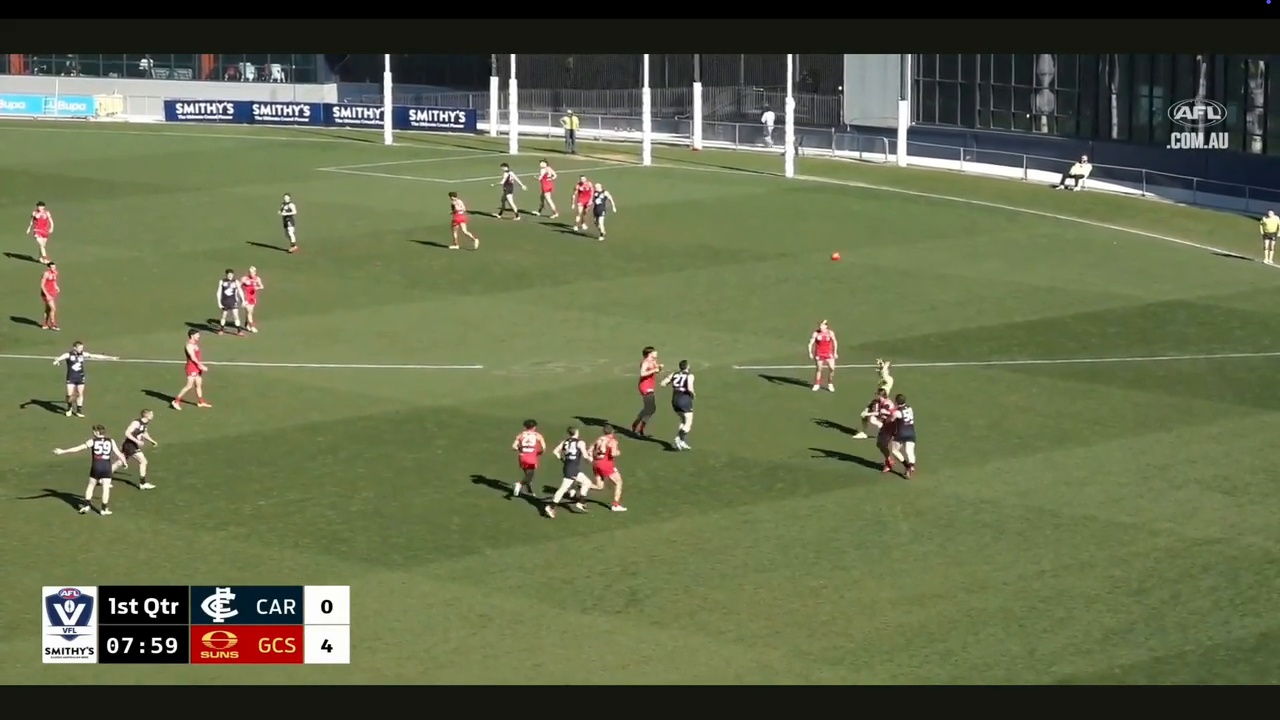

Event ID: 11
Frame range: 15820 to 15841
Video time: 08:48 to 08:49
Middle frame: 15830


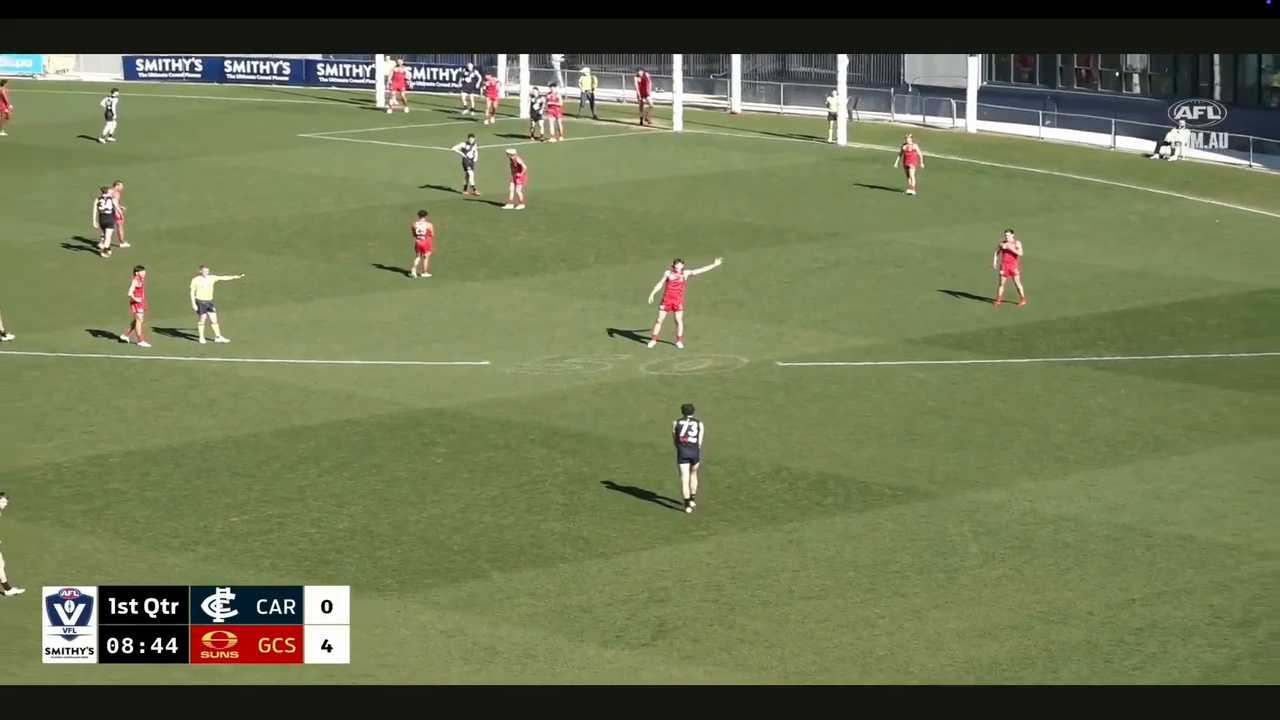

Event ID: 12
Frame range: 15859 to 15864
Video time: 08:49 to 08:50
Middle frame: 15861


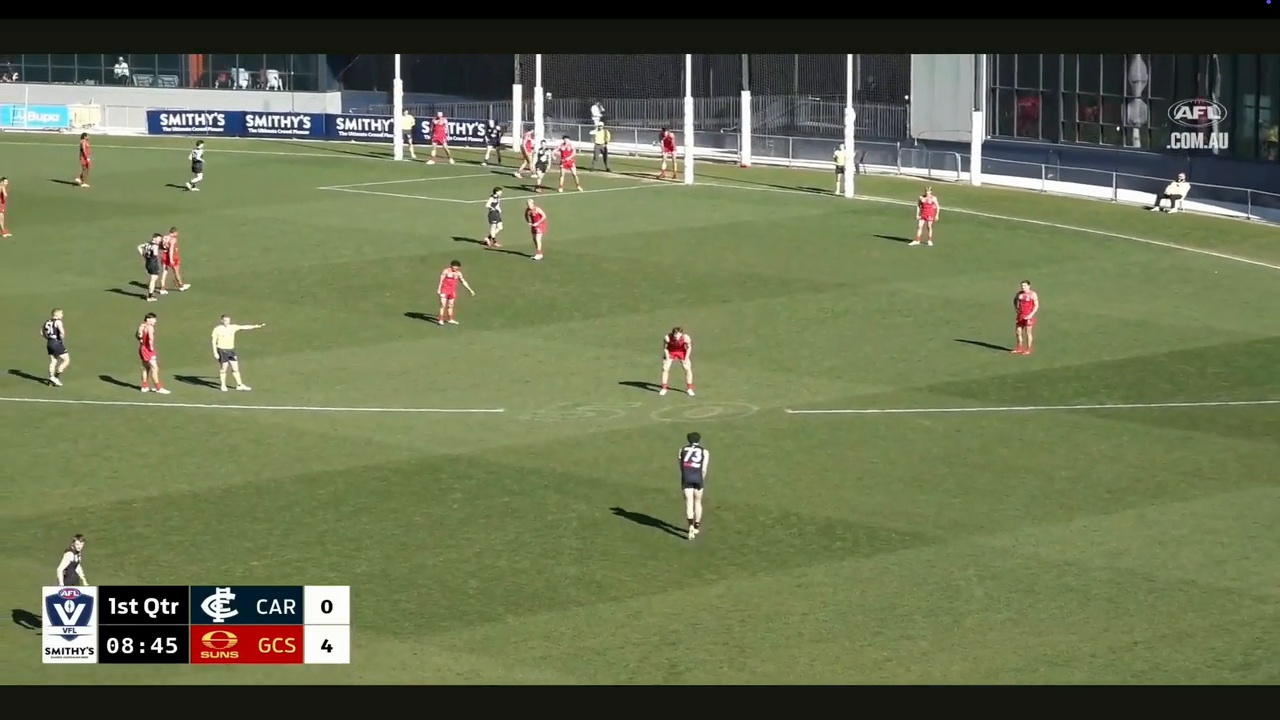

Event ID: 13
Frame range: 15906 to 15941
Video time: 08:51 to 08:52
Middle frame: 15923


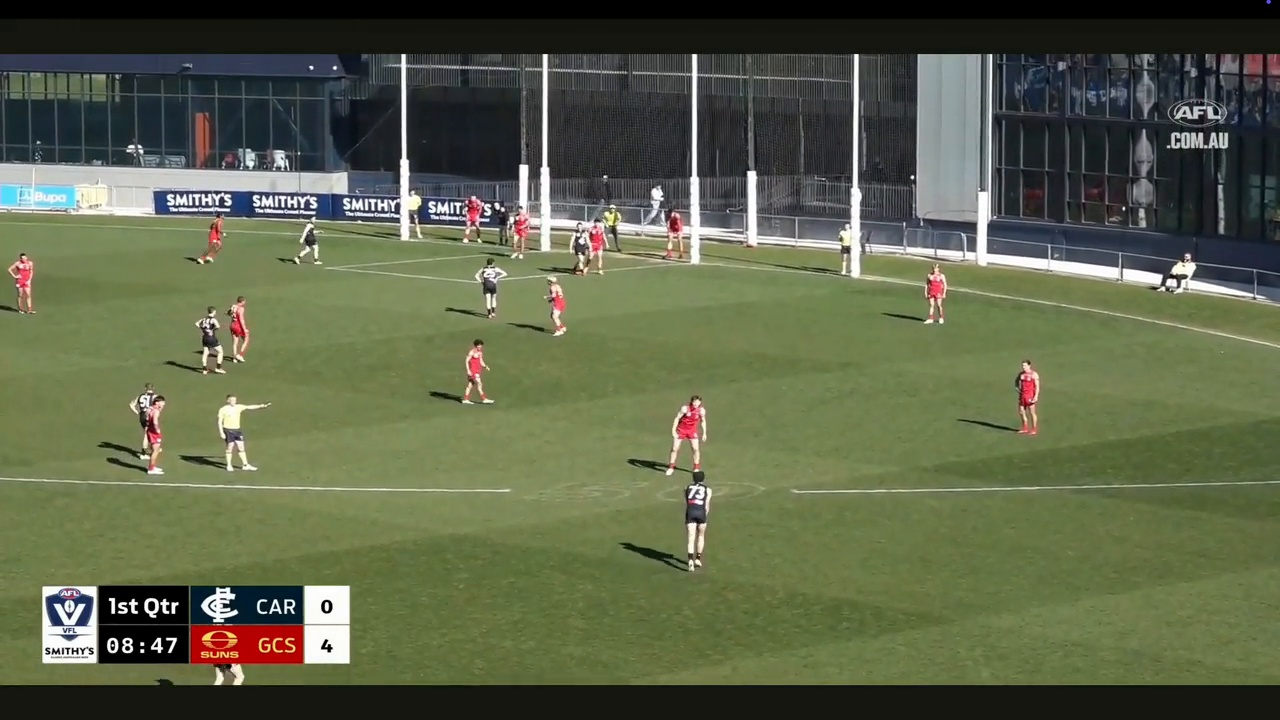

Event ID: 14
Frame range: 15962 to 16025
Video time: 08:53 to 08:55
Middle frame: 15993


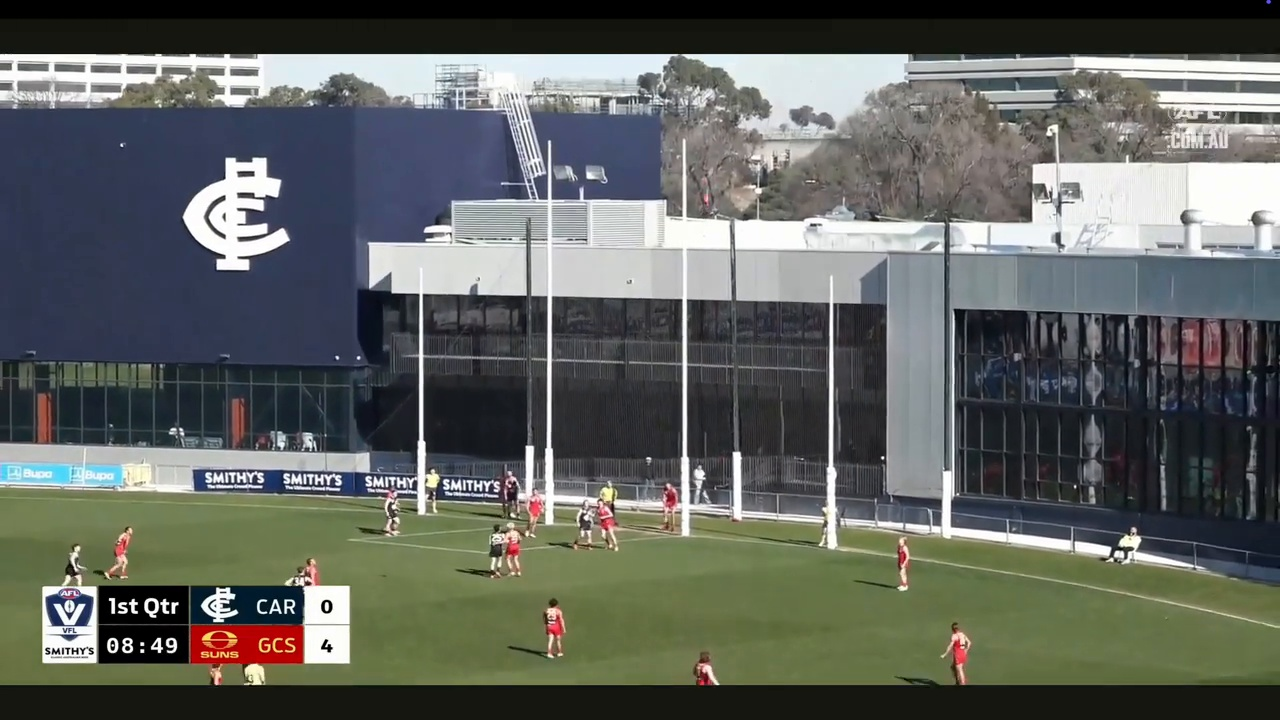

Event ID: 15
Frame range: 17843 to 17854
Video time: 09:56 to 09:56
Middle frame: 17848


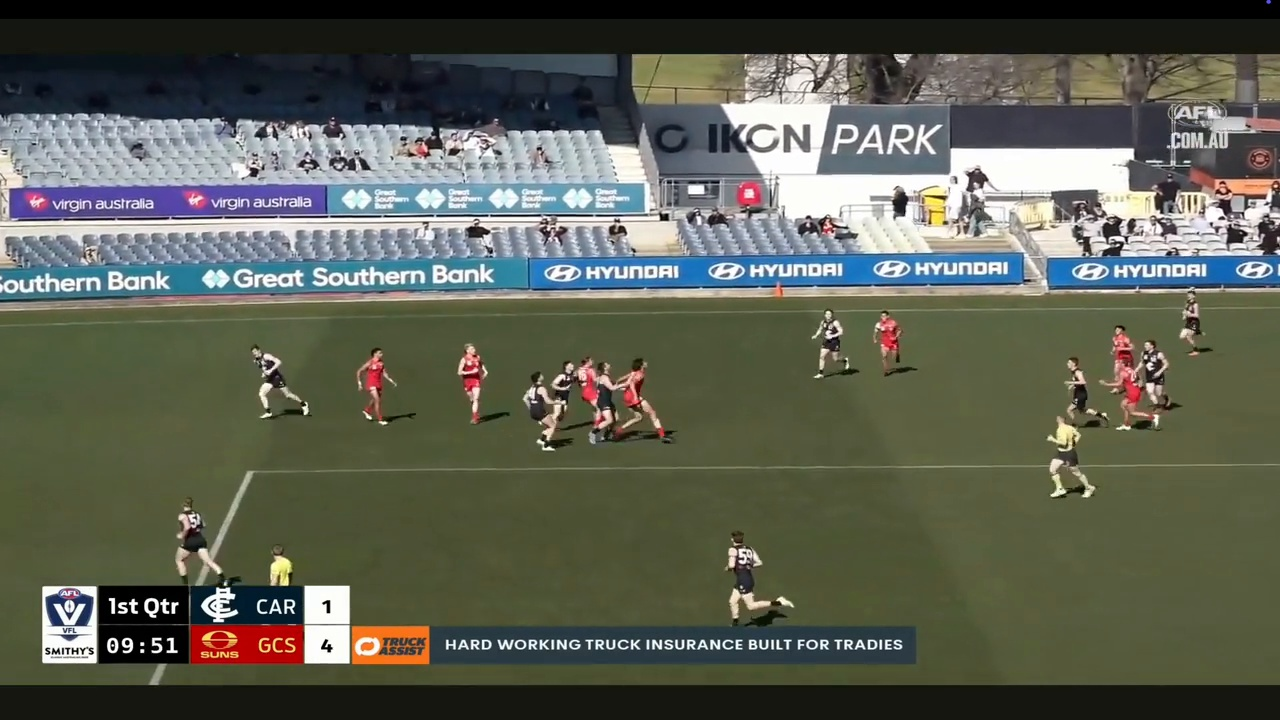

Event ID: 16
Frame range: 17891 to 17936
Video time: 09:57 to 09:59
Middle frame: 17913


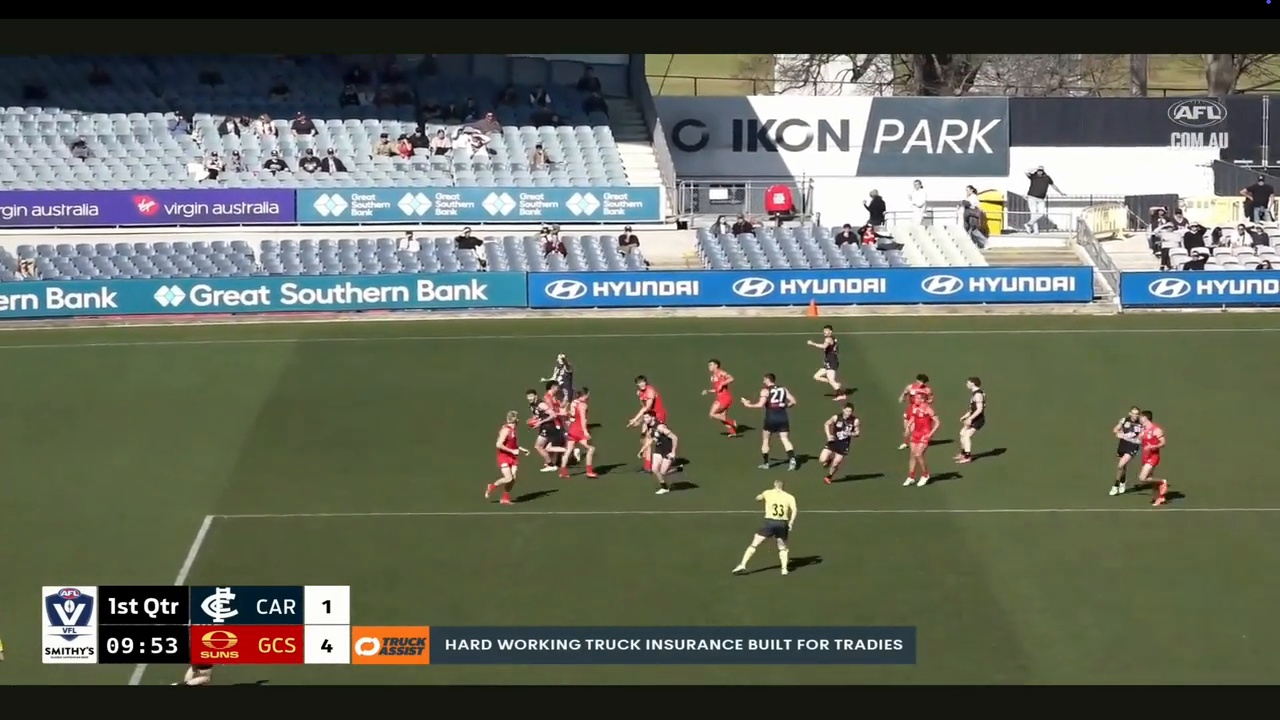

In [ ]:
for _, row in events_to_process.iterrows():
    print("=" * 70)
    print("Event ID:", row["event_id"])
    print("Frame range:", row["start_frame"], "to", row["end_frame"])
    print("Video time:", row["start_time"], "to", row["end_time"])
    print("Middle frame:", row["middle_frame"])

    if row["preview_image"] not in ["Frame extraction failed", "Frame outside video range"]:
        display(Image(filename=row["preview_image"]))
    else:
        print(row["preview_image"])

In [ ]:
validation_df = events_to_process.copy()

def auto_validate_tackle_event(row):
    event_length = int(row["end_frame"]) - int(row["start_frame"]) + 1

    if event_length >= 30:
        actual_result = "Likely Tackle"
        confidence = "High"
        notes = "The event lasts for a longer frame range, suggesting sustained player clustering or contact."

    elif event_length >= 15:
        actual_result = "Possible Tackle"
        confidence = "Medium"
        notes = "The event lasts for a moderate frame range, which may indicate a tackle-like interaction."

    elif event_length >= 5:
        actual_result = "Possible Tackle"
        confidence = "Low"
        notes = "The event is short, so it may represent brief contact, player overlap or a possible false positive."

    else:
        actual_result = "Possible False Positive"
        confidence = "Low"
        notes = "The event is very short, so there is not enough frame evidence to confirm a tackle."

    return pd.Series([actual_result, confidence, notes])

validation_df[["actual_result", "confidence", "validation_notes"]] = validation_df.apply(
    auto_validate_tackle_event,
    axis=1
)

display(validation_df)

,event_id,start_frame,end_frame,start_time,end_time,middle_frame,preview_image,actual_result,confidence,validation_notes
0,1,2113,2119,01:10,01:10,2116,validation_frames/event_1_frame_2116.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."
1,2,3514,3544,01:57,01:58,3529,validation_frames/event_2_frame_3529.jpg,Likely Tackle,High,"The event lasts for a longer frame range, sugg..."
2,3,3556,3580,01:58,01:59,3568,validation_frames/event_3_frame_3568.jpg,Possible Tackle,Medium,"The event lasts for a moderate frame range, wh..."
3,4,3592,3601,02:00,02:00,3596,validation_frames/event_4_frame_3596.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."
4,5,5089,5097,02:50,02:50,5093,validation_frames/event_5_frame_5093.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."
5,6,5123,5141,02:51,02:51,5132,validation_frames/event_6_frame_5132.jpg,Possible Tackle,Medium,"The event lasts for a moderate frame range, wh..."
6,7,5193,5199,02:53,02:53,5196,validation_frames/event_7_frame_5196.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."
7,8,5538,5542,03:05,03:05,5540,validation_frames/event_8_frame_5540.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."
8,9,14172,14186,07:53,07:54,14179,validation_frames/event_9_frame_14179.jpg,Possible Tackle,Medium,"The event lasts for a moderate frame range, wh..."
9,10,14492,14502,08:04,08:04,14497,validation_frames/event_10_frame_14497.jpg,Possible Tackle,Low,"The event is short, so it may represent brief ..."


In [ ]:
print("Validation Summary:")

if validation_df["actual_result"].replace("", pd.NA).dropna().empty:
    print("No validation labels have been entered yet.")
else:
    display(validation_df["actual_result"].value_counts().reset_index().rename(
        columns={
            "index": "result_type",
            "actual_result": "count"
        }
    ))

Validation Summary:


,count,count
0,Possible Tackle,12
1,Likely Tackle,4


In [ ]:
validation_df.to_csv(VALIDATION_OUTPUT, index=False)

print("Validation CSV saved as:", VALIDATION_OUTPUT)

Validation CSV saved as: tackle_event_validation.csv


In [ ]:
files.download(VALIDATION_OUTPUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("validation_frames", "zip", OUTPUT_FOLDER)

files.download(ZIP_OUTPUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>